# **Spam Mail Detector using Naive Bayes**

Step 1: Import Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Step 2: Download NLTK Resources

In [16]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Step 3: Load Dataset

In [17]:
from google.colab import files

# Upload the spam.csv file
uploaded = files.upload()

# You can verify the uploaded file(s)
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving spam.csv to spam.csv
User uploaded file "spam.csv" with length 503663 bytes


In [18]:
dataset = pd.read_csv("spam.csv", encoding="latin-1")

dataset.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Step 4: Keep Required Columns



In [19]:
dataset = dataset[['v1','v2']]

dataset.columns = ['Label','Message']

dataset.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Step 5: Explore Dataset

In [20]:
print(dataset.shape)

print(dataset.info())

print(dataset['Label'].value_counts())

(5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Label    5572 non-null   object
 1   Message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
Label
ham     4825
spam     747
Name: count, dtype: int64


Step 6: Check Missing Values

In [21]:
print(dataset.isnull().sum())

Label      0
Message    0
dtype: int64


Step 7: Text Preprocessing

In [22]:
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))

def preprocess(text):

    text = text.lower()

    words = word_tokenize(text)

    words = [
        word for word in words
        if word.isalpha() and word not in stop_words
    ]

    return " ".join(words)

dataset['Clean_Message'] = dataset['Message'].apply(preprocess)

dataset.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,Label,Message,Clean_Message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts may...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though


Step 8: Convert Labels

In [23]:
dataset['Label'] = dataset['Label'].map({
    'ham':0,
    'spam':1
})

Step 9: Convert Text into TF-IDF Features

In [24]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(dataset['Clean_Message'])

Y = dataset['Label']

### Alternative: Using CountVectorizer

While TF-IDF considers the importance of a word in a document relative to the corpus, a `CountVectorizer` simply counts the occurrences of words. Let's see how to initialize and use it.

In [25]:
# Ensure 'dataset' is loaded and 'Clean_Message' column is created by previous cells.
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer()

X_count = count_vectorizer.fit_transform(dataset['Clean_Message'])

print("Shape of feature matrix using CountVectorizer:", X_count.shape)
print("First 5 feature names:", count_vectorizer.get_feature_names_out()[:5])

Shape of feature matrix using CountVectorizer: (5572, 7138)
First 5 feature names: ['aa' 'aah' 'aaniye' 'aaooooright' 'aathi']


Step 10: Split Dataset

In [26]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

Step 11: Train Naive Bayes Model

In [27]:
model = MultinomialNB()

model.fit(X_train,Y_train)

MultinomialNB()

Step 12: Make Predictions

In [28]:
predictions = model.predict(X_test)

Step 13: Model Evaluation

In [29]:
accuracy = accuracy_score(Y_test,predictions)

print("Accuracy:",accuracy)

Accuracy: 0.9650224215246637


In [30]:
print(classification_report(Y_test,predictions))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.74      0.85       150

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



In [31]:
cm = confusion_matrix(Y_test,predictions)

print(cm)

[[965   0]
 [ 39 111]]


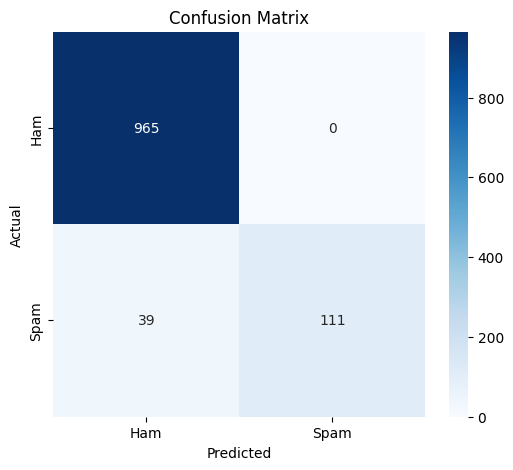

In [32]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham','Spam'],
    yticklabels=['Ham','Spam']
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

Step 14: Test with Your Own Message

In [33]:
message = [
    "Congratulations! You have won a free iPhone. Click here to claim now."
]

message = [preprocess(message[0])]

message_vector = vectorizer.transform(message)

prediction = model.predict(message_vector)

if prediction[0] == 1:
    print("Spam Mail")
else:
    print("Ham Mail")

Spam Mail


Step 15: Test Another Example

In [34]:
message = [
    "Hi Herman, can we meet tomorrow for the project discussion?"
]

message = [preprocess(message[0])]

message_vector = vectorizer.transform(message)

prediction = model.predict(message_vector)

if prediction[0] == 1:
    print("Spam Mail")
else:
    print("Ham Mail")

Ham Mail
